In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [62]:
data_dir = '/mnt/home/srafilson/code/sequences/results_20260618/full_fit/N_151'
restarts = os.listdir(data_dir)
restarts = [f for f in restarts if f.startswith("restart_")]
likelihoods = np.zeros(len(restarts))
print(f"Found {len(restarts)} restarts")
nMissing = 0
for restart in restarts:
    data_path = f"{data_dir}/{restart}/fitted_model.npz"
    if not os.path.exists(data_path):
        nMissing += 1
        print(f"Missing data for {restart}")
        continue
    data = np.load(data_path, allow_pickle=True)
    likelihoods[restarts.index(restart)] = data["training_likelihoods"][-1]

# set zero likelihoods to -inf for better visualization
likelihoods[likelihoods == 0] = -np.inf

print(f"Missing data for {nMissing} restarts / {len(restarts)} total restarts")

# save the likelihoods to np file
np.save(f"{data_dir}/likelihoods.npy", likelihoods)

Found 2529 restarts
Missing data for restart_358
Missing data for restart_141
Missing data for restart_325
Missing data for restart_2494
Missing data for restart_69
Missing data for restart_2486
Missing data for restart_45
Missing data for restart_91
Missing data for restart_377
Missing data for restart_199
Missing data for restart_207
Missing data for restart_206
Missing data for restart_329
Missing data for restart_210
Missing data for restart_223
Missing data for restart_297
Missing data for restart_68
Missing data for restart_214
Missing data for restart_283
Missing data for restart_2472
Missing data for restart_2471
Missing data for restart_2505
Missing data for restart_2493
Missing data for restart_76
Missing data for restart_2436
Missing data for restart_2447
Missing data for restart_413
Missing data for restart_379
Missing data for restart_2435
Missing data for restart_74
Missing data for restart_39
Missing data for restart_183
Missing data for restart_37
Missing data for resta

KeyboardInterrupt: 

In [64]:
# load the likelihoods from the np file
likelihoods = np.load(f"{data_dir}/likelihoods.npy")

In [65]:
# set zero likelihoods to -inf for better visualization
likelihoods[likelihoods == 0] = -np.inf

In [66]:
sns.set_context('talk')

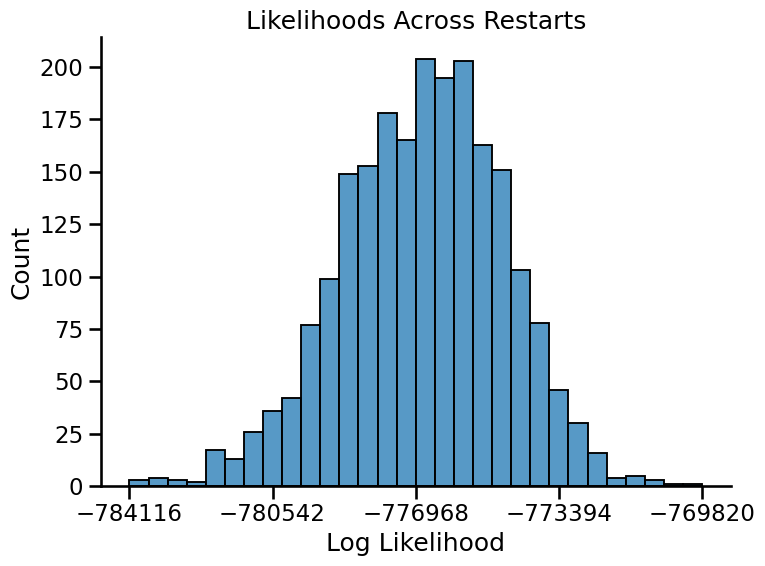

In [67]:
# plot the distribution of likelihoods across restarts
plt.figure(figsize=(8, 6))
sns.histplot(likelihoods, bins=30)
plt.xlabel("Log Likelihood")
plt.title("Likelihoods Across Restarts")
# only show 5 x ticks for better visualization
min = np.min(likelihoods[likelihoods != -np.inf])
max = np.max(likelihoods)
plt.xticks(np.linspace(min, max, 5))
plt.tight_layout()
sns.despine()
plt.show()


In [68]:
# get the best likelihood and corresponding parameters
best_idx = np.argmax(likelihoods)

# get the parameters for the best fit
best_restart = restarts[best_idx]
best_data_path = f"{data_dir}/{best_restart}/fitted_model.npz"
best_data = np.load(best_data_path, allow_pickle=True)

A = best_data["A"]
B = best_data["B"]
pi = best_data["pi"]
training_llh = best_data["training_likelihoods"]

print(B.shape)


# Reorder observation columns (neurons) according to the state that emits each observation with the highest probability.
state_order = np.argsort(np.argmax(B, axis=0))
B_sorted = B[:, state_order]




(151, 100)


In [69]:
# set back to default context
sns.set_context('notebook')

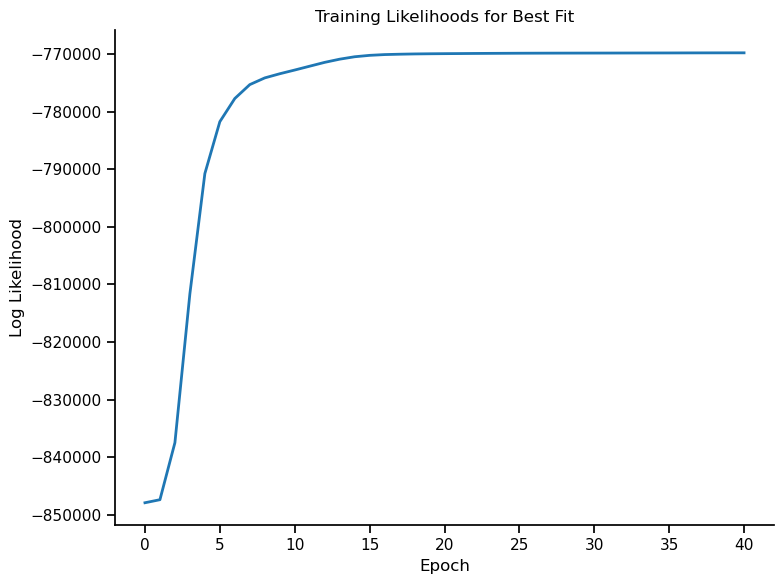

In [70]:
# plot the training likelihoods
plt.figure(figsize=(8, 6))
plt.plot(training_llh, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Log Likelihood")
plt.title("Training Likelihoods for Best Fit")
plt.tight_layout()
sns.despine()
plt.show()


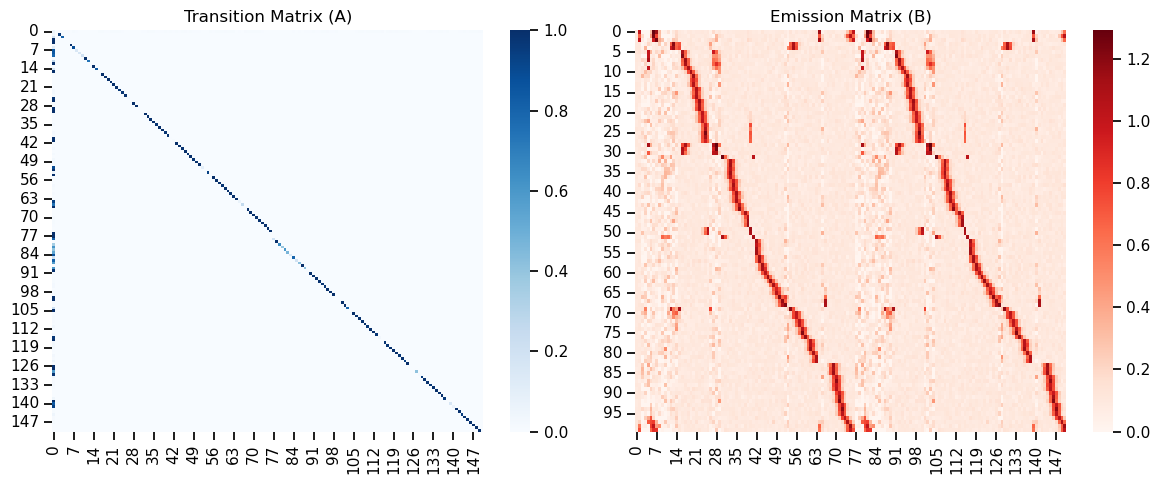

In [71]:
# plot the A and B matrices
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(A, ax=axs[0], cmap="Blues")
axs[0].set_title("Transition Matrix (A)")
sns.heatmap(B_sorted.T, ax=axs[1], cmap="Reds")
axs[1].set_title("Emission Matrix (B)")
plt.tight_layout()
plt.show()  

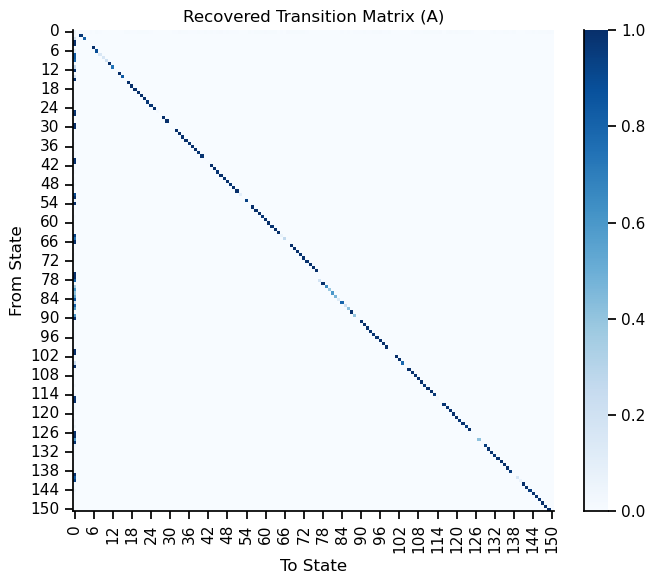

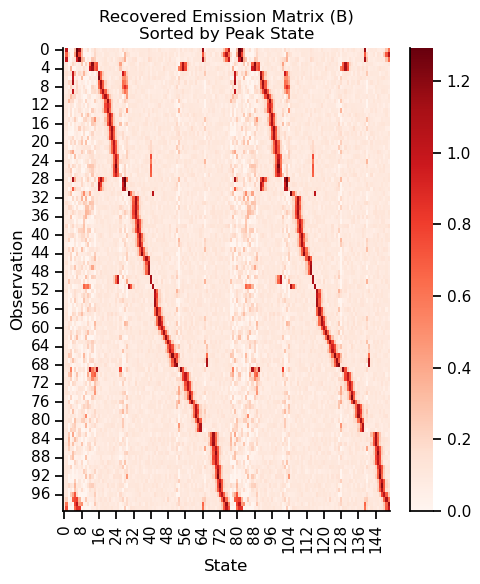

In [72]:
plt.figure(figsize=(7, 6))
sns.heatmap(A, cmap="Blues")
plt.title("Recovered Transition Matrix (A)")
plt.xlabel("To State")
plt.ylabel("From State")
plt.tight_layout()
sns.despine()
plt.show()


plt.figure(figsize=(5, 6))
sns.heatmap(B_sorted.T, cmap="Reds")
plt.title("Recovered Emission Matrix (B)\nSorted by Peak State")
plt.xlabel("State")
plt.ylabel("Observation")
plt.tight_layout()
sns.despine()
plt.show()

# load in the data and run inference on the best fit parameters to get the most likely state sequence and compare to the true state sequence if available.


In [73]:
from custom_hmm import PoissonHMM, initialization, make_transition_update_mask

data_path = '/mnt/home/srafilson/code/sequences/results_20260618/cloned-HMM-simulated-data-2026-06-07-13-28-49/simulated_data.npz'
data = np.load(data_path, allow_pickle=True)

# get the observations and true states from the data
observations = data["observations"]
true_states = data["states"]

model = PoissonHMM(
    A=A,
    B=B,
    pi=pi
)

model.set_observations(observations)

states = model.viterbi()




/mnt/home/srafilson/code/sequences/custom_hmm.py:29: RuntimeWarning: divide by zero encountered in log
  self.log_pi = np.log(self.pi)


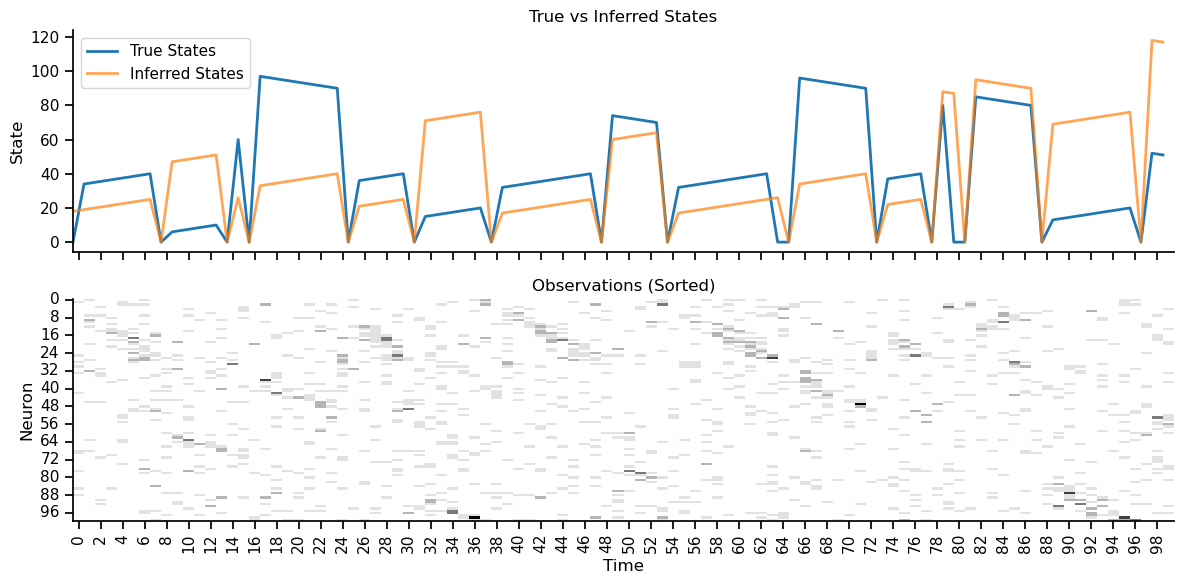

In [76]:
# plot a few seconds of the true states and inferred states with the emissions below

start_time = 0
end_time = 100

fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axs[0].plot(true_states[start_time:end_time], label="True States", linewidth=2)
axs[0].plot(states[start_time:end_time], label="Inferred States", linewidth=2, alpha=0.7)
axs[0].set_title("True vs Inferred States")
axs[0].set_ylabel("State")
axs[0].legend()

# plot the observations sorted according to B_sorted
sns.heatmap(observations[start_time:end_time][:, state_order].T, ax=axs[1], cmap="Greys", cbar=False)
axs[1].set_title("Observations (Sorted)")
axs[1].set_xlabel("Time")
axs[1].set_ylabel("Neuron")
plt.tight_layout()
sns.despine()
plt.show()
